<a href="https://colab.research.google.com/github/corebankingfiap-dev/core_banking/blob/main/00_Data_Lake_Consolidacao_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ele é o "Cérebro" que lê apenas os arquivos que estão na sua camada 03_Gold.

Mounted at /content/drive
🚀 Consolidando setores para visão de Portfólio...


/tmp/ipykernel_696/3393013721.py:66: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(path_reports, "EVOLUCAO_PATRIMONIAL_LIGA.png"), bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


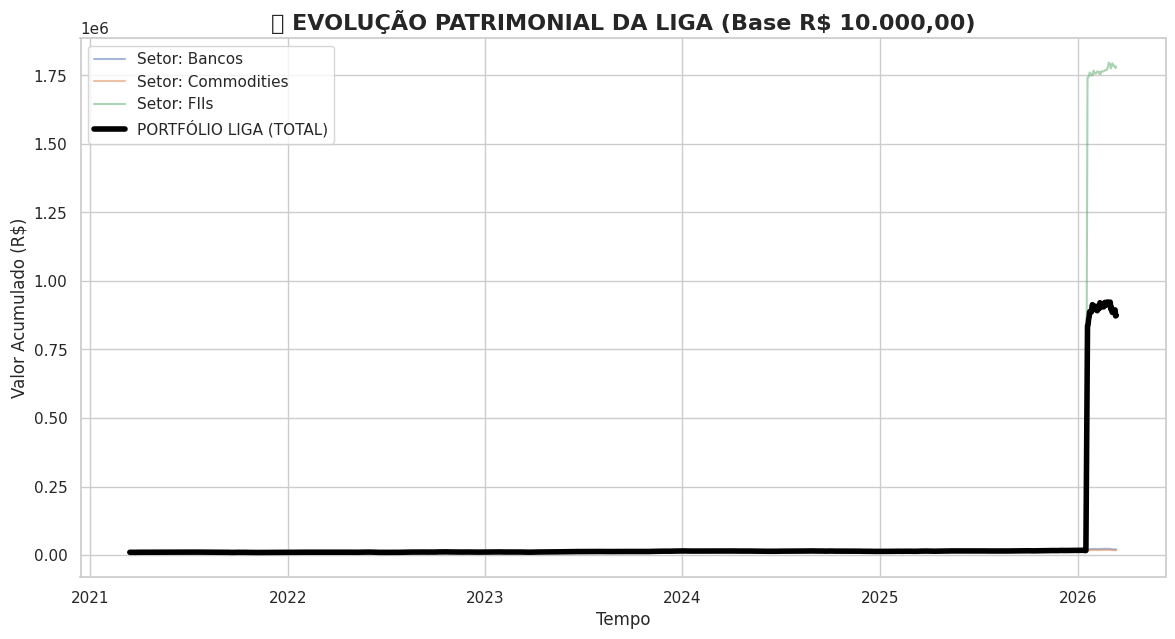


🏆 PERFORMANCE ACUMULADA DO PORTFÓLIO:
Bancos            104.35%
Commodities        72.99%
FIIs           17,719.43%
LIGA_TOTAL      8,637.13%
Name: 2026-03-13 00:00:00, dtype: object


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# 1. Conexão e Caminhos (Sincronizado com suas fotos)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PATH_SILVER = '/content/drive/MyDrive/DATA_LAKE/02_Silver/'
PATH_GOLD = '/content/drive/MyDrive/DATA_LAKE/03_Gold/'

def carregar_e_processar_setor(segmento):
    # Lendo os dados técnicos (limpos) da Silver para ter precisão diária
    caminho = os.path.join(PATH_SILVER, f'b3_{segmento}_limpo.csv')
    if os.path.exists(caminho):
        df = pd.read_csv(caminho, index_col=0, parse_dates=True)
        # Calculando o retorno médio diário do setor (equipesadas)
        retorno_setor = df.pct_change().mean(axis=1)
        return retorno_setor
    else:
        print(f"⚠️ Alerta: Arquivo de {segmento} não encontrado.")
        return pd.Series()

# 2. Criando o Portfólio Consolidado
print("🚀 Consolidando setores para visão de Portfólio...")

ret_bancos = carregar_e_processar_setor("bancos")
ret_commo = carregar_e_processar_setor("commodities")
ret_fiis = carregar_e_processar_setor("fiis")

# Unificando tudo em um único DataFrame
df_port = pd.DataFrame({
    'Bancos': ret_bancos,
    'Commodities': ret_commo,
    'FIIs': ret_fiis
}).fillna(0) # Preenche feriados cruzados com zero

# Calculando a média total da LIGA
df_port['LIGA_TOTAL'] = df_port.mean(axis=1)

# Transformando retornos em evolução patrimonial (Base R$ 10.000)
# Usamos o produto acumulado (cumprod)
df_evolucao = (1 + df_port).cumprod() * 10000

# 3. Visualização de Dono da Gestora
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Plotando os setores com linhas finas
for coluna in ['Bancos', 'Commodities', 'FIIs']:
    plt.plot(df_evolucao.index, df_evolucao[coluna], label=f'Setor: {coluna}', alpha=0.5, linewidth=1.5)

# Plotando a linha principal (O valor total da Liga) com destaque
plt.plot(df_evolucao.index, df_evolucao['LIGA_TOTAL'], label='PORTFÓLIO LIGA (TOTAL)', color='black', linewidth=4)

plt.title("📈 EVOLUÇÃO PATRIMONIAL DA LIGA (Base R$ 10.000,00)", fontsize=16, fontweight='bold')
plt.ylabel("Valor Acumulado (R$)")
plt.xlabel("Tempo")
plt.legend(loc='upper left')

# Salvando o gráfico no seu Reports
path_reports = os.path.join(PATH_GOLD, 'REPORTS')
os.makedirs(path_reports, exist_ok=True)
plt.savefig(os.path.join(path_reports, "EVOLUCAO_PATRIMONIAL_LIGA.png"), bbox_inches='tight')

plt.show()

# Relatório Final de Fechamento
print("\n🏆 PERFORMANCE ACUMULADA DO PORTFÓLIO:")
performance = ((df_evolucao.iloc[-1] / 10000 - 1) * 100)
print(performance.map("{:,.2f}%".format))